In [121]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys
sys.path.append('/home/ae19663/artiq')  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402

def get_override_args(filename, hide_defaults=True):
    vals = {}

    f1 = h5py.File(filename, "r")
    args = pyon.decode(f1["expid"][()])["arguments"]
    for k, v in args.items():
        if k == "ndscan_params":
            params = pyon.decode(args["ndscan_params"])
            overrides = params["overrides"]
            for k, v in overrides.items():
                spec = params["schemata"][k]["spec"]
                val = v[0]["value"]
                default = type(val)(params["schemata"][k]["default"])
                if hide_defaults and val == default:
                    continue
                vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
        else:
            vals[k] = [v, ""]
    return vals

vals = get_override_args("../results/2025-07-08/21/000006529-AbsorptionImageExpFrag.h5")


for k, (v, unit) in vals.items():
    print(f"{k} = {v} {unit}")

absorption_image.AbsorptionImageExpFrag.exposure_time = 0.2 ms
absorption_image.AbsorptionImageExpFrag.expansion_time = 10.0 ms
absorption_image.AbsorptionImageExpFrag.do_pgc = 0.0 
absorption_image.AbsorptionImageExpFrag.do_odt = 0.0 
repository.fragments.mot.MOT.ODT_duration = 10.0 ms
repository.fragments.mot.MOT.CMOT_detuning = 8.0 Γ
repository.fragments.mot.MOT.CMOT_duration = 10.0 ms
repository.fragments.mot.MOT.CMOT_settle_time = 0.0 ms
repository.fragments.mot.MOT.loading_time = 30.0 s
repository.fragments.mot.MOT.ODT_overlap_time = 10.0 ms


Images.All.0
<class 'str'>
Images.All.1
<class 'str'>
Images.All.2
<class 'str'>
Images.Latest_image
<class 'str'>
Images.absorption.BG
<class 'str'>
Images.absorption.REF
<class 'str'>
Images.absorption.TOF
<class 'str'>
Images.absorption.expansion_time
<class 'str'>
Images.absorption.timestamp
<class 'str'>
ndscan.rid_6517.analysis_results
<class 'str'>
ndscan.rid_6517.annotations
<class 'str'>
ndscan.rid_6517.axes
<class 'str'>
ndscan.rid_6517.channels
<class 'str'>
ndscan.rid_6517.completed
<class 'str'>
ndscan.rid_6517.fragment_fqn
<class 'str'>
ndscan.rid_6517.ndscan_schema_revision
<class 'str'>
ndscan.rid_6517.online_analyses
<class 'str'>
ndscan.rid_6517.point.atom_number
<class 'str'>
ndscan.rid_6517.point.info
<class 'str'>
ndscan.rid_6517.point_phase
<class 'str'>
ndscan.rid_6517.seed
<class 'str'>
ndscan.rid_6517.source_id
<class 'str'>


(<Figure size 800x800 with 6 Axes>,
 [<Axes: title={'center': 'Atoms'}>,
  <Axes: title={'center': 'Reference'}>,
  <Axes: title={'center': 'Background'}>,
  <Axes: title={'center': 'Optical Density'}, xlabel='Horizontal position (mm)', ylabel='Vertical position (mm)'>,
  <Axes: ylabel='Electron Count'>,
  <Axes: ylabel='Optical Density'>])

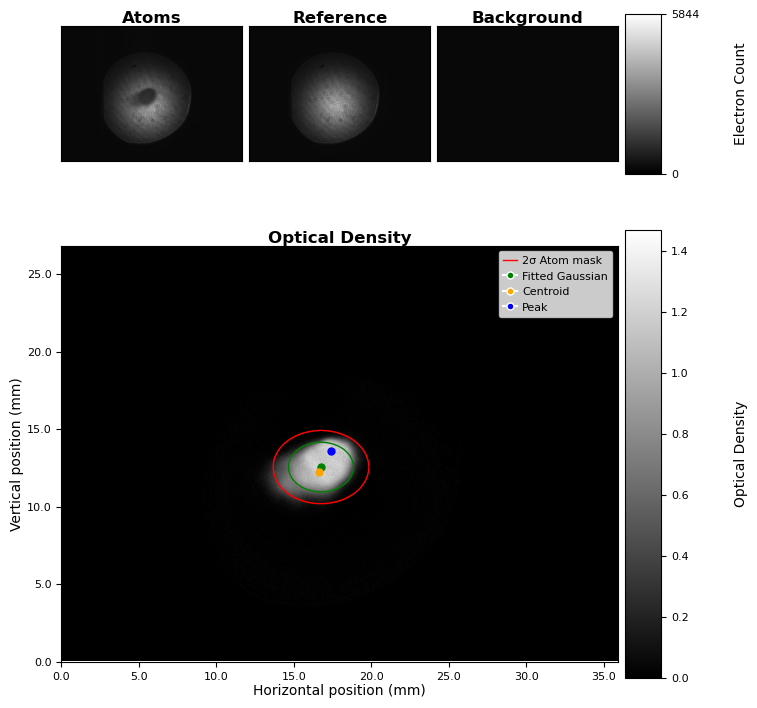

In [122]:
# Plot and fit the data for the temprature extraction
files=os.listdir("../results/2025-07-08/21/")


file_num = []
file_name = []
for i in files:
    #shorting with the file name splitting the file name into two parts and then shorting with the file number and then combining
    file_num.append(i.split("-")[0])
    file_name.append(i.split("-")[1])

# shorting the file name and file number
file_num, file_name = zip(*sorted(zip(file_num, file_name)))

# Recombine the file number and file name into a single list
files = [f"{num}-{name}" for num, name in zip(file_num, file_name)]


# Directory list for the files shorted file names
files_directory = [f"../results/2025-07-08/21/{f}" for f in files if f.endswith(".h5")]


# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")

for i in f1["datasets"].keys():
    print(i)
    print(type(i))


absimg = AbsImage(
    data=f1["datasets"]["Images.absorption.TOF"][()],
    ref=f1["datasets"]["Images.absorption.REF"][()],
    bg=f1["datasets"]["Images.absorption.BG"][()],
    magnification=0.25,  # Set default magnification
)

absimg.plot()
